In [530]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
project_root = Path.cwd().parents[1]

In [3]:
words = open(project_root / "data/names.txt", 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
# Build the vocabulary of characters and mappings to/from integer
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [5]:
block_size = 3
X, y = [], []

for w in words[:5]:
    print("----------------------")
    print(w)
    context = [0] * block_size
    
    for ch in w + '.':
        X.append(context)
        y.append(stoi[ch])
        print(''.join(itos[i] for i in context), '---->', ch)
        context = context[1:] + [stoi[ch]]



----------------------
emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
----------------------
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
----------------------
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
----------------------
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
----------------------
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [ ]:
block_size = 3
X, y = [], []

for w in words:
    context = [0] * block_size
    
    for ch in w + '.':
        X.append(context)
        iy = stoi[ch]
        y.append(iy)
        context = context[1:] + [iy]

In [8]:
X = torch.tensor(X)
y = torch.tensor(y)

X.shape, y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [9]:
C = torch.randn(27, 3)

In [34]:
# Both are equivalent but indexing is much more faster
print(C[5])
print(F.one_hot(torch.tensor(5), num_classes=27).float() @ C)

tensor([-0.7484, -0.0836,  0.6213])
tensor([-0.7484, -0.0836,  0.6213])


In [40]:
C[X].shape

torch.Size([228146, 3, 3])

### Neural Network

In [61]:
block_size = 3
X, y = [], []

for w in words:
    context = [0] * block_size
    
    for ch in w + '.':
        X.append(context)
        iy = stoi[ch]
        y.append(iy)
        context = context[1:] + [iy]

In [62]:
X = torch.tensor(X)
y = torch.tensor(y)

In [63]:
emb_dim = 2
vocab_size = 27

C = torch.randn(vocab_size, emb_dim)

emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [64]:
# Doesn't create a copy if emb is contiguous
emb = emb.reshape(-1, block_size * emb_dim)
emb.shape

torch.Size([228146, 6])

In [65]:
W1 = torch.randn((100, block_size * emb_dim))
b1 = torch.randn(100)

In [69]:
h = torch.tanh(emb @ W1.T + b1)
h.shape

torch.Size([228146, 100])

In [ ]:
W2 = torch.randn(27, 100)
b2 = torch.randn(27)

In [72]:
logits = h @ W2.T + b2
logits.shape

torch.Size([228146, 27])

In [74]:
counts = logits.exp()
prob = counts / counts.sum(dim=1, keepdim=True)
prob.shape, prob[0].sum()

(torch.Size([228146, 27]), tensor(1.0000))

In [84]:
loss = -torch.log(prob[torch.arange(len(X)), y]).mean()
loss

tensor(16.8354)

In [85]:
# Much more efficient and numerically stable
F.cross_entropy(logits, y)

tensor(16.8355)

### Training Loop

In [106]:

block_size = 3
X, y = [], []

for w in words:
    context = [0] * block_size
    
    for ch in w + '.':
        X.append(context)
        iy = stoi[ch]
        y.append(iy)
        context = context[1:] + [iy]


In [107]:
X = torch.tensor(X)
y = torch.tensor(y)

X.shape, y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [407]:
emb_dim = 3
vocab_size = 27
hidden_size = 100
g = torch.Generator().manual_seed(214789)
C = torch.randn(vocab_size, emb_dim, requires_grad=True, generator=g) # (27, 2)
W1 = torch.randn((hidden_size, block_size * emb_dim), requires_grad=True, generator=g) # (100, 6)
b1 = torch.randn(hidden_size, requires_grad=True, generator=g)
W2 = torch.randn((vocab_size, hidden_size), requires_grad=True, generator=g)
b2 = torch.randn(vocab_size, requires_grad=True, generator=g)

params = [C, W1, W2, b1, b2]

In [408]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre # Exponentially stepping through the learning rate

In [414]:
### Finding the optimal LR
epochs = 1000
batch_size = 64
N = len(X)
lri = []
lossi = []


for i in range(epochs):
    ix = torch.randint(0, N, (batch_size, ) )
    x_b = X[ix]
    y_b = y[ix]
    # Forward pass
    X_emb = C[x_b].reshape(-1, emb_dim * block_size)
    h = torch.tanh(X_emb @ W1.T + b1)
    logits = h @ W2.T + b2 
    loss = F.cross_entropy(logits, y_b)

    # Backward pass
    for p in params:
        p.grad = None # zero grad
    
    # Backward
    loss.backward()

    # Gradient Descent
    lr = lrs[i]
    for p in params:
            p.data -= lr * p.grad

    #Tracking
    lri.append(lre[i])
    lossi.append(loss.item())
    
    print(loss.item())

    

5.139575481414795
4.547750949859619
5.1005377769470215
6.740106582641602
5.104043006896973
5.905681133270264
5.068124771118164
4.912142753601074
6.403006553649902
4.883608341217041
5.820070743560791
4.584334373474121
5.322925567626953
5.5376973152160645
5.7115044593811035
5.590057373046875
5.880833148956299
5.156501770019531
5.290524959564209
4.71161413192749
4.892327308654785
4.864711284637451
4.984437465667725
4.643688678741455
4.470324516296387
4.443488597869873
6.417283058166504
5.006793975830078
4.60630989074707
5.164132118225098
5.713163375854492
4.7540740966796875
5.828389644622803
4.805440902709961
4.869564056396484
5.444333076477051
4.425781726837158
5.131472110748291
5.233998775482178
5.431145191192627
4.19282865524292
4.99160623550415
4.913787364959717
4.525357723236084
4.590165138244629
5.398327350616455
4.385870933532715
4.586582660675049
6.159409999847412
4.798773765563965
5.160669803619385
5.135865211486816
5.2511491775512695
5.13682222366333
4.8288984298706055
5.6448421

Text(0, 0.5, 'loss')

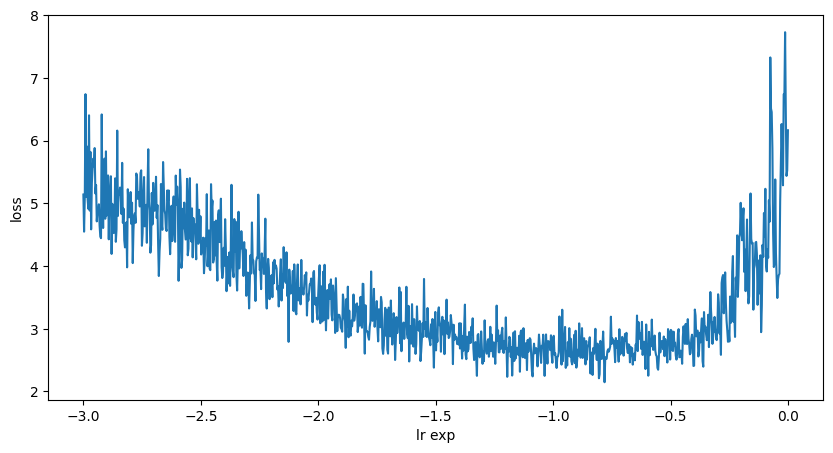

In [417]:
plt.figure(figsize=(10,5))
plt.plot(lri, lossi)
plt.xlabel('lr exp')
plt.ylabel('loss') 

### Final

In [694]:
block_size = 4

def build_dataset(words):
    X, y = [], []

    for w in words:
        context = [0] * block_size
        
        for ch in w + '.':
            X.append(context)
            iy = stoi[ch]
            y.append(iy)
            context = context[1:] + [iy]
    
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y

In [695]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, ytr = build_dataset(words[:n1])
Xdev, ydev = build_dataset(words[n1:n2])
Xte, yte = build_dataset(words[n2:])

torch.Size([182400, 4]) torch.Size([182400])
torch.Size([22962, 4]) torch.Size([22962])
torch.Size([22784, 4]) torch.Size([22784])


In [696]:
emb_dim = 10
vocab_size = 27
hidden_size = 300
g = torch.Generator().manual_seed(214789)
C = torch.randn(vocab_size, emb_dim, generator=g) * 0.1

W1 = torch.randn((hidden_size, block_size * emb_dim), generator=g) * ((block_size * emb_dim) ** -0.5)
b1 = torch.zeros(hidden_size)
W2 = torch.randn((vocab_size, hidden_size), generator=g) * (hidden_size ** -0.5)
b2 = torch.zeros(vocab_size)

params = [C, W1, W2, b1, b2]

for p in params:
    p.requires_grad = True

In [697]:
epochs = 200000
batch_size = 128
N = len(Xtr)


for i in range(epochs):
    ix = torch.randint(0, N, (batch_size, ) )
    x_b = Xtr[ix]
    y_b = ytr[ix]
    # Forward pass
    X_emb = C[x_b].reshape(-1, emb_dim * block_size)
    h = torch.tanh(X_emb @ W1.T + b1)
    logits = h @ W2.T + b2 
    loss = F.cross_entropy(logits, y_b)

    # Backward pass
    for p in params:
        p.grad = None # zero grad
    loss.backward()

    # Gradient Descent
    lr = 0.1 if i < 10000 else 0.01
    for p in params:
            p.data -= lr * p.grad

    if i % 1000 == 0:
        print(f"Train loss: {loss.item():.4f}")


Train loss: 3.3246
Train loss: 2.3702
Train loss: 2.3611
Train loss: 2.1988
Train loss: 2.4394
Train loss: 2.2862
Train loss: 2.3234
Train loss: 2.1362
Train loss: 2.4978
Train loss: 2.2587
Train loss: 2.1679
Train loss: 2.2168
Train loss: 2.1451
Train loss: 2.2348
Train loss: 2.3422
Train loss: 2.1597
Train loss: 2.1920
Train loss: 2.2087
Train loss: 2.2064
Train loss: 2.1522
Train loss: 2.1952
Train loss: 2.2028
Train loss: 2.2199
Train loss: 2.1096
Train loss: 2.1164
Train loss: 2.1042
Train loss: 2.1418
Train loss: 2.2267
Train loss: 2.1689
Train loss: 2.3194
Train loss: 2.0944
Train loss: 2.0576
Train loss: 2.3028
Train loss: 2.0722
Train loss: 2.3604
Train loss: 2.1876
Train loss: 2.0793
Train loss: 2.4242
Train loss: 2.1698
Train loss: 2.1716
Train loss: 2.1268
Train loss: 2.2989
Train loss: 2.3739
Train loss: 1.9559
Train loss: 1.9035
Train loss: 2.2675
Train loss: 2.2681
Train loss: 2.2964
Train loss: 2.2152
Train loss: 2.1436
Train loss: 2.1994
Train loss: 2.1764
Train loss: 

In [698]:
 # Val loss
X_dev_emb = C[Xdev].reshape(-1, emb_dim * block_size)
h = torch.tanh(X_dev_emb @ W1.T + b1)
logits = h @ W2.T + b2 
val_loss = F.cross_entropy(logits, ydev)
val_loss.item()

2.09196138381958

In [699]:
# Test Loss
X_emb = C[Xte].reshape(-1, emb_dim * block_size)
h = torch.tanh(X_emb @ W1.T + b1)
logits = h @ W2.T + b2 
test_loss = F.cross_entropy(logits, yte)
test_loss.item()

2.0938661098480225

In [703]:
for _ in range(15):
    out = []
    context = [0] * block_size
    
    while True:
        x_emb = C[context].reshape(-1, emb_dim*block_size)
        h = torch.tanh(x_emb @ W1.T + b1)
        logits = h @ W2.T + b2
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdim=True)
        ix = torch.multinomial(probs, num_samples=1, replacement=True).item()
        if ix == 0:
            break
        out.append(itos[ix])

        context = context[1:] + [ix]
    print(''.join(out))


kaina
mory
samdad
bella
hadis
wourne
chev
zith
annielsette
blayelder
devi
alec
romarionni
denei
jorkar
